# **TASK - 1: TITANIC SURVIVAL PREDICTION**

***Author:** ZUNAIRA FATIMA*

***Batch:** JUNE-26*

***Domain**: Data Science*

# **AIM :**
*To develop a machine learning model using the Kaggle Titanic dataset to predict whether a passenger survived the Titanic disaster.*

## **The project is divided into three phases:**

*   Data Preprocessing,
*   Data Analytics (EDA),
*   and Model Building.

*Through these phases, the data is cleaned, analyzed, and used to train a predictive model that identifies the key factors affecting passenger survival and provides accurate survival predictions.*

In [23]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


**Phase: 1 Data Preprocessing**

In [ ]:
#Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
test_data = pd.read_csv('Titanic-Dataset.csv')

In [ ]:
test_data.shape

(891, 12)

In [ ]:
test_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
test_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
test_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Droping unnecessary columns which we don't need**

In [ ]:
#droping cabin bcz it is having so many missing values
test_data = test_data.drop(['Cabin'], axis =1)

In [ ]:
#Droping these columns bcz they're not necessary for our project
test_data = test_data.drop(['PassengerId','Name','Ticket'], axis=1)


**After droping all unnecessary columns we'll print our required columns.**

In [ ]:
print(test_data.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [ ]:
#filling missing age with median value
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

In [ ]:
#filling missing 'Embarked' with mode(most common value)

test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

In [ ]:
#now we'll check null values in our dataset
test_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


**Now we'll check the Data types of our columns**

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


*`The dataset contains object-type columns. Since machine learning models work with numerical data, these columns must be converted into integer values before model training.`*

In [ ]:
#Changing 'Sex' column object data type into 'int' so that we can do "ML" Operations further.
mapping = {'male': 1, 'female': 0}
test_data['Sex'] = test_data['Sex'].map(mapping)


In [ ]:
#Changing 'Embarked' column object data type into 'int' so that we can do "ML" Operations further.
mapping = {'C': 0, 'Q': 1, 'S': 2}
test_data['Embarked'] = test_data['Embarked'].map(mapping)

In [ ]:
#Checking data types again!
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


*After checking the data types again, we can see that all categorical (object) columns have been converted into numerical values. The dataset now contains only integer and float data types, making it ready for machine learning operations.*

In [ ]:
#Displaying the first few rows of the processed dataset to verify that data cleaning and preprocessing have been completed successfully.
test_data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,3,1,28.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
7,0,3,1,2.0,3,1,21.0750,2
8,1,3,0,27.0,0,2,11.1333,2
9,1,2,0,14.0,1,0,30.0708,0


**We have completed our first phase, which is Data Preprocessing. The dataset is now cleaned, transformed, and ready for data analysis and model building.**

**Phase: 2 Data Analysis (EDA)**

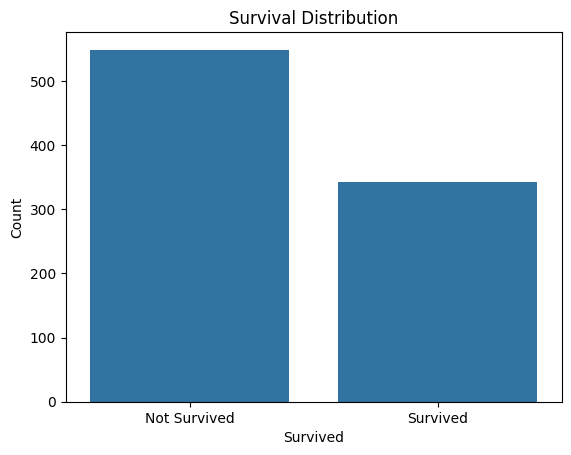

In [28]:
#Survival Distribution(Bar chart)
sns.countplot(x='Survived', data=test_data)
plt.title('Survival Distribution')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.ylabel('Count')
plt.show()

***Insight:***
*Most passengers did not survive.Dataset is slightly imbalanced toward non-survivors.Survival rate is around 38%, while 62% passengers died.*

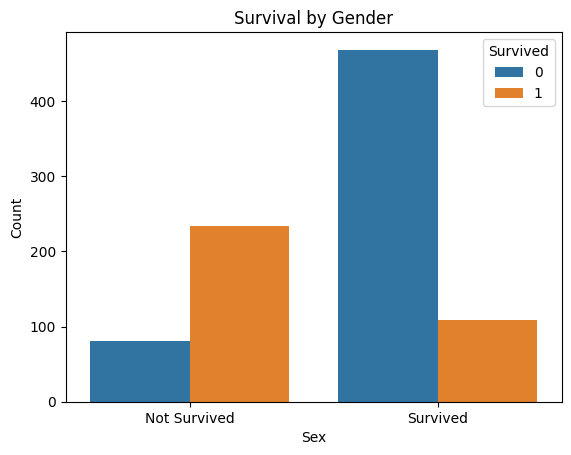

In [29]:
#Survival by Gender(Count Plot)
sns.countplot(x='Sex', hue='Survived', data=test_data)
plt.title('Survival by Gender')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.ylabel('Count')
plt.show()

***Insight:***
*0 stands for Female and 1 stands for Male. Female passengers had a significantly higher survival rate, while Male passengers had a lower survival rate*

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

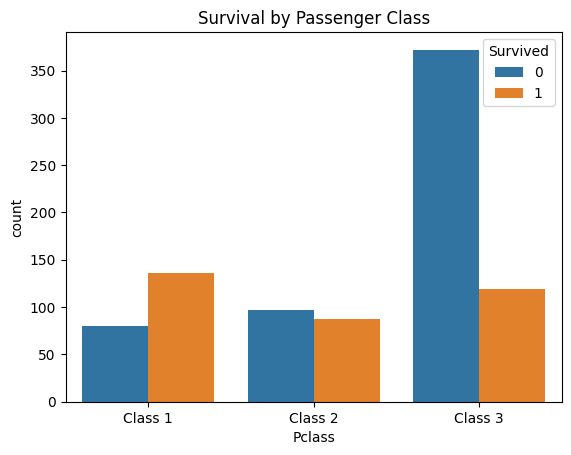

In [30]:
# Survival by Passenger Class(Pclass)
sns.countplot(x='Pclass', hue='Survived', data=test_data)
plt.title('Survival by Passenger Class')
plt.xticks([0, 1, 2], ['Class 1', 'Class 2', 'Class 3'])
plt

***Insight:***
*First-class passengers had the highest survival rate. Third-class passengers had the lowest survival rate*.

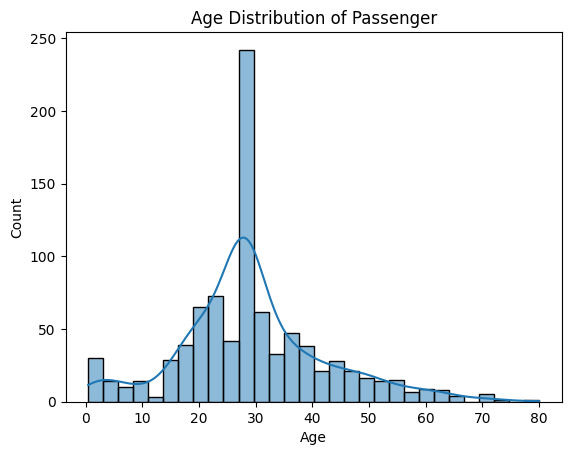

In [31]:
# Age Distribution of Passenger(Histogram)
sns.histplot(data=test_data, x='Age', kde=True)
plt.title('Age Distribution of Passenger')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

***Insight:***
*Most passengers were aged between 20 and 40 years, with the highest number around 30 years. The number of passengers decreases as age moves toward the younger and older groups.*

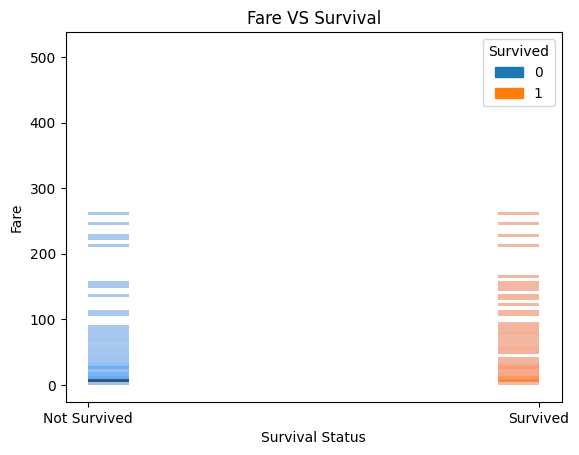

In [38]:
sns.histplot(data=test_data, x='Survived', kde=True, hue='Survived', y='Fare')
plt.title('Fare VS Survival')
plt.xticks([0,1], ['Not Survived', 'Survived']) # Set x-axis ticks and labels
plt.xlabel('Survival Status') # Set the x-axis label
plt.ylabel('Fare')
plt.show()

***Insight:***
*Passengers paying higher fares generally survived more often. Higher fares are associated with higher classes. So, Wealthier passengers had better access to lifeboats and safer locations.*

**Phase: 3 Building a ML model**

*Before proceeding to the model building phase, the dataset is checked once again to ensure that all columns have the correct data types, contain no missing values, and are ready for machine learning operations.*

In [39]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [40]:
#Importing necessary Library for ml operations
from sklearn.model_selection import train_test_split

In [41]:
# Spliting the data into Train and Test Sets
x = test_data.drop('Survived', axis=1)
y = test_data['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=42)

In [43]:
#Import the Logistic Regression model from the sklearn.linear_model library
from sklearn.linear_model import LogisticRegression
model= LogisticRegression (max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [44]:
y_pred = model.predict(x_test)
print(y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


Importing evaluation metrics from scikit - learn to measure model performance

**accuracy_score :** computes the overall accuracy of the model

**confusion_matrix :** displays true/false positive and negative

**classification_report :** provide precision,recall, F1-scpre and support for each class.

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877


# **So, Model is 81% accurate, which is pretty good.**
# **It is slightly better at predicting non-survivors class(0) than survivors class(1)**

In [47]:
print("\nClassification Report:\n",  classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# **Precision and recall are decent, and f1-score is also in a** **good range(0.76 - 0.84).**

In [49]:
#Create confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[90 15]
 [19 55]]


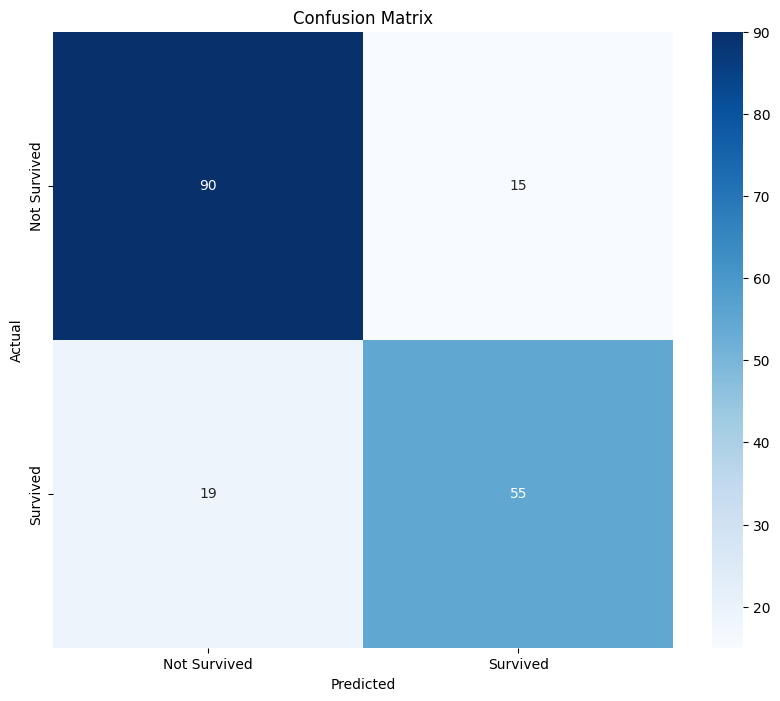

In [50]:
# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels= ["Not Survived", "Survived"], yticklabels= ["Not Survived", "Survived"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Model Performance Analysis (Confusion Matrix)**

- **The model correctly predicted that 90 passengers did not survive.**
- **The model incorrectly predicted that 15 passengers survived, although they actually did not survive.**
- **The model incorrectly predicted that 19 passengers did not survive, although they actually survived.**
- **The model correctly predicted that 55 passengers survived.**

**Conclusion:**
*The model performed well in predicting passenger survival outcomes, correctly classifying the majority of passengers. However, a small number of passengers were misclassified, indicating that there is still room for improvement in prediction accuracy.*